# Step 1 — Hindcast Evaluation of SCI Ensemble
## CO₂ Emissions (Energy and Industrial Processes)

Three metrics (ME, MAE, RMSE) × three views (by year, by scenario, overall).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# EACH USER: update this path to your local SCI data folder
SCI_DATA = Path.home() / 'PhD' / '4. Modeling' / 'Prisma School' / 'Scenario_Compass_Initiative_Data'
SCI_FILE = SCI_DATA / 'SCI-2025_v1.0_pathways_ensemble_global.xlsx'
print('Path:', SCI_DATA)
print('Exists:', SCI_DATA.exists())

Path: /Users/remipaccou/PhD/4. Modeling/Prisma School/Scenario_Compass_Initiative_Data
Exists: True


## Load data (takes 1-2 min)

In [2]:
df = pd.read_excel(SCI_FILE, sheet_name='data')
meta = pd.read_excel(SCI_FILE, sheet_name='meta')
print(f'Loaded: {len(df)} rows, {df["Model"].nunique()} models')

Loaded: 548541 rows, 65 models


In [3]:
meta['nz_year'] = pd.to_numeric(meta['Emissions Diagnostics|Year of Net Zero|CO2'], errors='coerce')
meta['nz2070'] = meta['nz_year'].notna() & (meta['nz_year'] <= 2070)
meta['key'] = meta['Model'] + '|||' + meta['Scenario']
nz_keys = set(meta.loc[meta['nz2070'], 'key'])
print(f'NZ2070 scenarios: {len(nz_keys)}')

NZ2070 scenarios: 497


## Compute errors
$$\varepsilon_{j,t} = y_{\text{observed},t} - \hat{y}_{j,t}$$

In [4]:
VARIABLE = 'Emissions|CO2|Energy and Industrial Processes'
YEARS = ['2010', '2015', '2020', '2025']
OBS = {'2010': 33400, '2015': 35400, '2020': 34800, '2025': 38100}

s = df[df['Variable'] == VARIABLE].copy()
s['key'] = s['Model'] + '|||' + s['Scenario']
s['nz2070'] = s['key'].isin(nz_keys)

for yr in YEARS:
    s[f'eps_{yr}'] = OBS[yr] - s[yr]

eps_cols = [f'eps_{yr}' for yr in YEARS]
eps_mat = s[eps_cols]
s['ME_j'] = eps_mat.mean(axis=1)
s['MAE_j'] = eps_mat.abs().mean(axis=1)
s['RMSE_j'] = np.sqrt((eps_mat ** 2).mean(axis=1))

n_nz = s['nz2070'].sum()
n_other = (~s['nz2070']).sum()
print(f'Scenarios: {len(s)} | NZ2070: {n_nz} | non-NZ: {n_other}')

Scenarios: 1591 | NZ2070: 497 | non-NZ: 1094


## View 1 — $\text{ME}_t$: averaged over scenarios
$$\text{ME}_t = \frac{1}{J} \sum_{j=1}^{J} \varepsilon_{j,t}$$

In [5]:
print(f'{"Year":<6} | {"ME":>10} | {"MAE":>10} | {"RMSE":>10}')
print('-' * 44)
for yr in YEARS:
    e = s[f'eps_{yr}'].dropna()
    print(f'{yr:<6} | {e.mean():>+10,.0f} | {e.abs().mean():>10,.0f} | {np.sqrt((e**2).mean()):>10,.0f}')

Year   |         ME |        MAE |       RMSE
--------------------------------------------
2010   |       +591 |        791 |      1,047
2015   |       -178 |      1,009 |      1,277
2020   |     -2,075 |      2,248 |      2,786
2025   |     +2,695 |      3,943 |      5,038


## View 2 — $\text{ME}_j$: averaged over time
$$\text{ME}_j = \frac{1}{|T|} \sum_{t \in T} \varepsilon_{j,t}$$

In [6]:
print(f'{"Group":<10} | {"ME_j":>8} | {"MAE_j":>8} | {"RMSE_j":>8} | {"n":>6}')
print('-' * 52)
for grp, label in [(None, 'All'), (True, 'NZ2070'), (False, 'non-NZ')]:
    sub = s if grp is None else s[s['nz2070'] == grp]
    print(f'{label:<10} | {sub["ME_j"].mean():>+8,.0f} | {sub["MAE_j"].mean():>8,.0f} | {sub["RMSE_j"].mean():>8,.0f} | {len(sub):>6d}')

Group      |     ME_j |    MAE_j |   RMSE_j |      n
----------------------------------------------------
All        |     +231 |    2,012 |    2,649 |   1591
NZ2070     |     +807 |    2,341 |    3,243 |    497
non-NZ     |      -30 |    1,863 |    2,379 |   1094


## View 3 — $\overline{\text{ME}}$: averaged over both
$$\overline{\text{ME}} = \frac{1}{J \cdot |T|} \sum_j \sum_t \varepsilon_{j,t}$$

In [7]:
all_eps = eps_mat.values.flatten()
all_eps = all_eps[~np.isnan(all_eps)]
eps_nz = eps_mat[s['nz2070'].values].values.flatten()
eps_nz = eps_nz[~np.isnan(eps_nz)]
eps_oth = eps_mat[~s['nz2070'].values].values.flatten()
eps_oth = eps_oth[~np.isnan(eps_oth)]

for name, fn in [('ME', np.mean), ('MAE', lambda x: np.mean(np.abs(x))), ('RMSE', lambda x: np.sqrt(np.mean(x**2)))]:
    print(f'{name:<5} | All: {fn(all_eps):>+8,.0f} | NZ: {fn(eps_nz):>+8,.0f} | non-NZ: {fn(eps_oth):>+8,.0f}')

ME    | All:     +244 | NZ:     +818 | non-NZ:      -19
MAE   | All:   +2,013 | NZ:   +2,344 | non-NZ:   +1,862
RMSE  | All:   +3,010 | NZ:   +3,634 | non-NZ:   +2,675


## 3×3 Figure

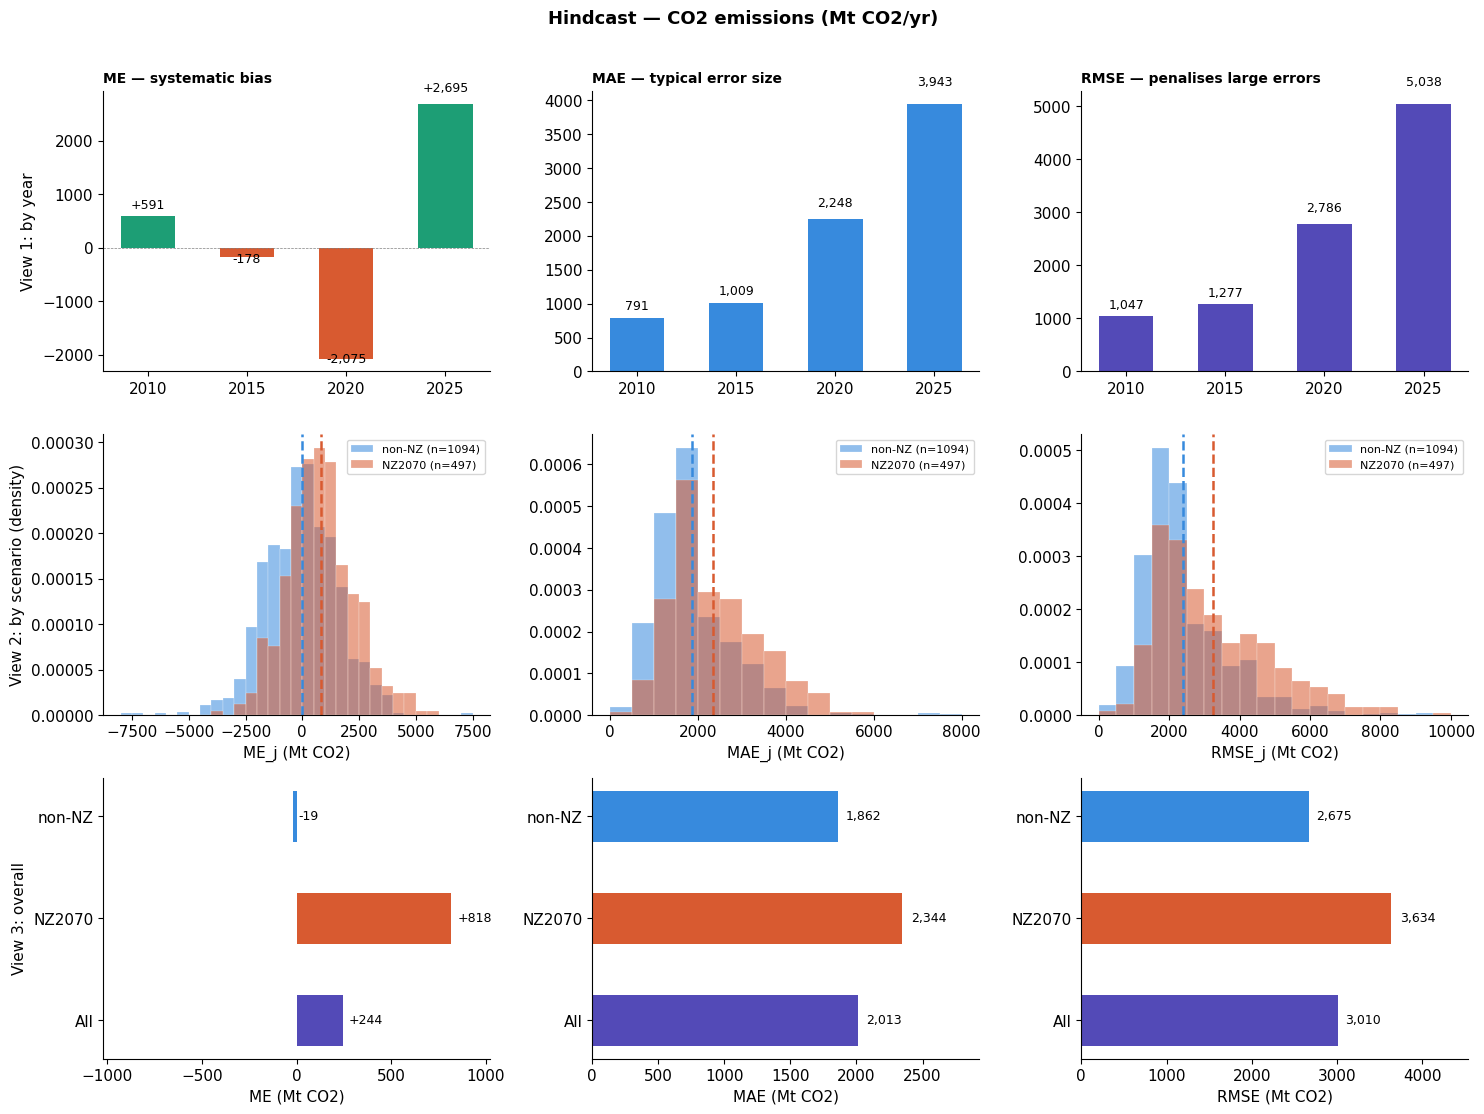

Saved: step1_co2_3x3.png


In [8]:
C_POS, C_NEG = '#1D9E75', '#D85A30'
C_NZ, C_OT, C_ALL = '#D85A30', '#378ADD', '#534AB7'

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('Hindcast — CO2 emissions (Mt CO2/yr)', fontsize=13, fontweight='bold', y=1.01)

metrics = [('ME','systematic bias',True), ('MAE','typical error size',False), ('RMSE','penalises large errors',False)]

for col, (mname, subtitle, signed) in enumerate(metrics):
    ax = axes[0, col]
    if mname=='ME':    vals=[s[f'eps_{yr}'].dropna().mean() for yr in YEARS]
    elif mname=='MAE': vals=[s[f'eps_{yr}'].dropna().abs().mean() for yr in YEARS]
    else:              vals=[np.sqrt((s[f'eps_{yr}'].dropna()**2).mean()) for yr in YEARS]
    colors=[C_POS if v>=0 else C_NEG for v in vals] if signed else [C_OT if mname=='MAE' else C_ALL]*4
    bars=ax.bar(YEARS,vals,color=colors,width=0.55)
    if signed: ax.axhline(0,color='gray',lw=0.5,ls='--')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+max(abs(v)*0.06,80),
                f'{v:+,.0f}' if signed else f'{v:,.0f}', ha='center', va='bottom' if (v>=0 or not signed) else 'top', fontsize=9)
    ax.set_title(f'{mname} — {subtitle}', fontsize=10, fontweight='bold', loc='left')
    if col==0: ax.set_ylabel('View 1: by year')
    ax.spines[['top','right']].set_visible(False)

    ax = axes[1, col]
    mcol = f'{mname}_j'
    v_nz=s.loc[s['nz2070'],mcol].dropna().values
    v_ot=s.loc[~s['nz2070'],mcol].dropna().values
    lo,hi=min(v_nz.min(),v_ot.min()),max(v_nz.max(),v_ot.max())
    bins=np.arange(np.floor(lo/500)*500, np.ceil(hi/500)*500+500, 500)
    ax.hist(v_ot,bins=bins,density=True,alpha=0.55,color=C_OT,label=f'non-NZ (n={len(v_ot)})',edgecolor='white',lw=0.3)
    ax.hist(v_nz,bins=bins,density=True,alpha=0.55,color=C_NZ,label=f'NZ2070 (n={len(v_nz)})',edgecolor='white',lw=0.3)
    ax.axvline(np.mean(v_ot),color=C_OT,lw=1.8,ls='--')
    ax.axvline(np.mean(v_nz),color=C_NZ,lw=1.8,ls='--')
    ax.legend(fontsize=8)
    ax.set_xlabel(f'{mname}_j (Mt CO2)')
    if col==0: ax.set_ylabel('View 2: by scenario (density)')
    ax.spines[['top','right']].set_visible(False)

    ax = axes[2, col]
    if mname=='ME':    v3=[np.mean(all_eps),np.mean(eps_nz),np.mean(eps_oth)]
    elif mname=='MAE': v3=[np.mean(np.abs(all_eps)),np.mean(np.abs(eps_nz)),np.mean(np.abs(eps_oth))]
    else:              v3=[np.sqrt(np.mean(all_eps**2)),np.sqrt(np.mean(eps_nz**2)),np.sqrt(np.mean(eps_oth**2))]
    bars3=ax.barh(['All','NZ2070','non-NZ'],v3,color=[C_ALL,C_NZ,C_OT],height=0.5)
    for bar,v in zip(bars3,v3):
        ax.text(v+max(abs(v)*0.03,30),bar.get_y()+bar.get_height()/2,
                f'{v:+,.0f}' if signed else f'{v:,.0f}',ha='left',va='center',fontsize=9)
    if col==0: ax.set_ylabel('View 3: overall')
    ax.set_xlabel(f'{mname} (Mt CO2)')
    ax.spines[['top','right']].set_visible(False)
    xmax=max(abs(v) for v in v3)*1.25
    ax.set_xlim((-xmax,xmax) if signed else (0,xmax))

plt.tight_layout()
plt.savefig('step1_co2_3x3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step1_co2_3x3.png')